<a href="https://colab.research.google.com/github/Soheilp86/Statistical-Machine-Learning/blob/main/24_MultipleLinearRegression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression

This notebook introduces regression. We will learn about:

- What is Regression Modeling?
- Simple Regression
- MultipleLinearRegression

## **Motivation: Predicting House Prices**



Suppose we want to predict the **price of a house**. We have information such as its size, number of bedrooms, age, and distance from downtown, denoted by $X_1, X_2, \ldots, X_p$. These are called **features**. We also know the price of each house, denoted by $y$.

We assume that the house price is related to its features through some function:

$$
y = f(X_1, X_2, \ldots, X_p) + \epsilon
$$

Here, $\epsilon$ represents the **error**.

In **linear regression**, we assume that $f$ can be approximated by a linear function:

$$
y = \beta_0+\beta_1X_1+\cdots+\beta_pX_p+\epsilon
$$

Here:

* $\beta_0,\ldots,\beta_p$ are the model **coefficients**.
* $\epsilon$ is the **error term**.

The goal is to use the features to make useful predictions.

Some important questions are:

* How well can we predict house prices?
* Which features are most useful?
* How does each feature affect the prediction?
* How large are our prediction errors?

## __Linear Regression (SLR):__


SLR is a regresson task that assumes the true relationship between the $X$, $y$ is a line (one variable):

$$
Y = \beta_0 + \beta_1X + \varepsilon  \quad (*)
$$


For example, in the following plot, we have some points $(x_i, y_i)$ and you can see a strong linear pattern in the data.

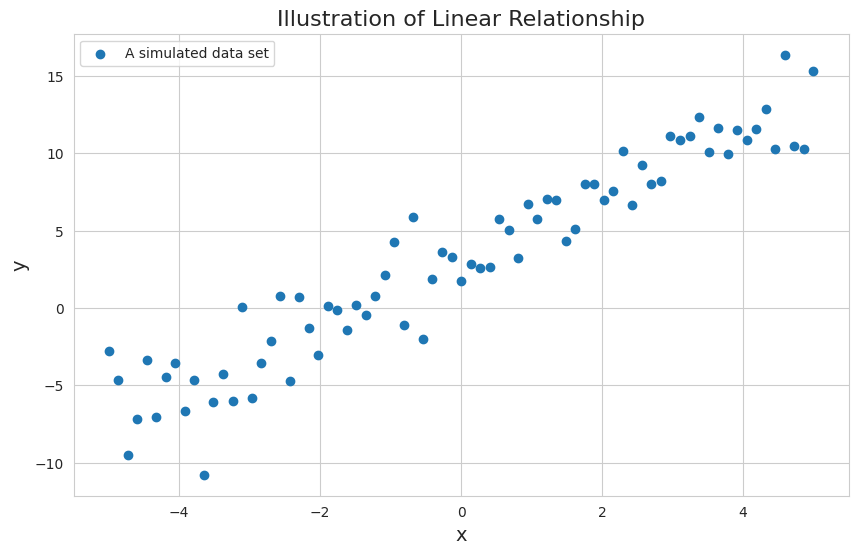

In [6]:
## Needed Libraries

## For data handling
import pandas as pd
import numpy as np

## For plotting
import matplotlib.pyplot as plt
import seaborn as sns

## This sets the plot style
## to have a grid on a white background (for readability of visualizations)
sns.set_style("whitegrid")

# This generates data that look line a line
x = np.linspace(-5, 5, 75) ## Domain of the line
y = 2 * x + 3 + 2 * np.random.randn(75)  ## Linear relationship with added random noise



# Plotting the dataset

# This creates a figure with a size of 10 units by 6 units
plt.figure(figsize=(10, 6))

# Plots the observed data using plt.scatter
plt.scatter(x, y, label="A simulated data set")

# Adds labels to the x and y axes for better readability
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)

# Adds a title to the plot
plt.title("Illustration of Linear Relationship", fontsize=16)

# Creates a legend based on the labels provided
plt.legend()

plt.show()


Look like a line so this linear relationship can be modeled as a general $Y = \beta_0 + \beta_1X$. But for which $\beta_0$ and $\beta_1X$ we get a line that describes the dataset better? Let's see an example.

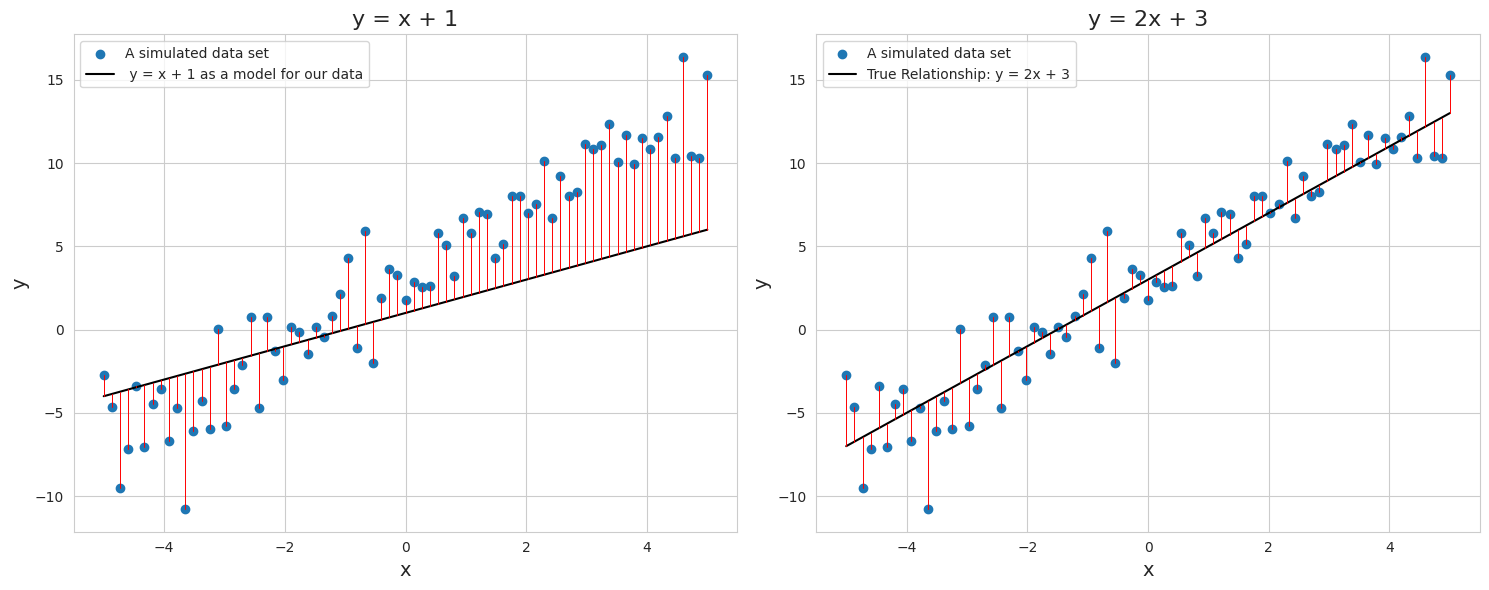

In [7]:
# Plotting
plt.figure(figsize=(15, 6))

# First subplot: Line: y = x + 1
plt.subplot(1, 2, 1)
plt.scatter(x, y, label="A simulated data set")
plt.plot(x, x + 1, color='black', linestyle='-', label=" y = x + 1 as a model for our data")
for i in range(len(x)):
    plt.plot([x[i], x[i]], [y[i], x[i] + 1], color='red', linestyle='-', linewidth=0.7)
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.title("y = x + 1", fontsize=16)
plt.legend()
plt.grid(True)

# Second subplot: True Relationship: y = 2x + 3
plt.subplot(1, 2, 2)
plt.scatter(x, y, label="A simulated data set")
plt.plot(x, 2*x + 3, color='black', linestyle='-', label="True Relationship: y = 2x + 3")
for i in range(len(x)):
    plt.plot([x[i], x[i]], [y[i], 2*x[i] + 3], color='red', linestyle='-', linewidth=0.7)
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.title("y = 2x + 3", fontsize=16)
plt.legend()
plt.grid(True)



plt.tight_layout()
plt.show()



Which model works better? Discuss in your group!

##**Multiple Linear Regression**

Multiple linear regression is the same idea as simple linear regression, but uses multiple features.

With two features, the model can be represented as a **plane** in 3D. With more than two features, the model becomes a **hyperplane** in higher dimensions.


Let's look at an example with two features in 3D.


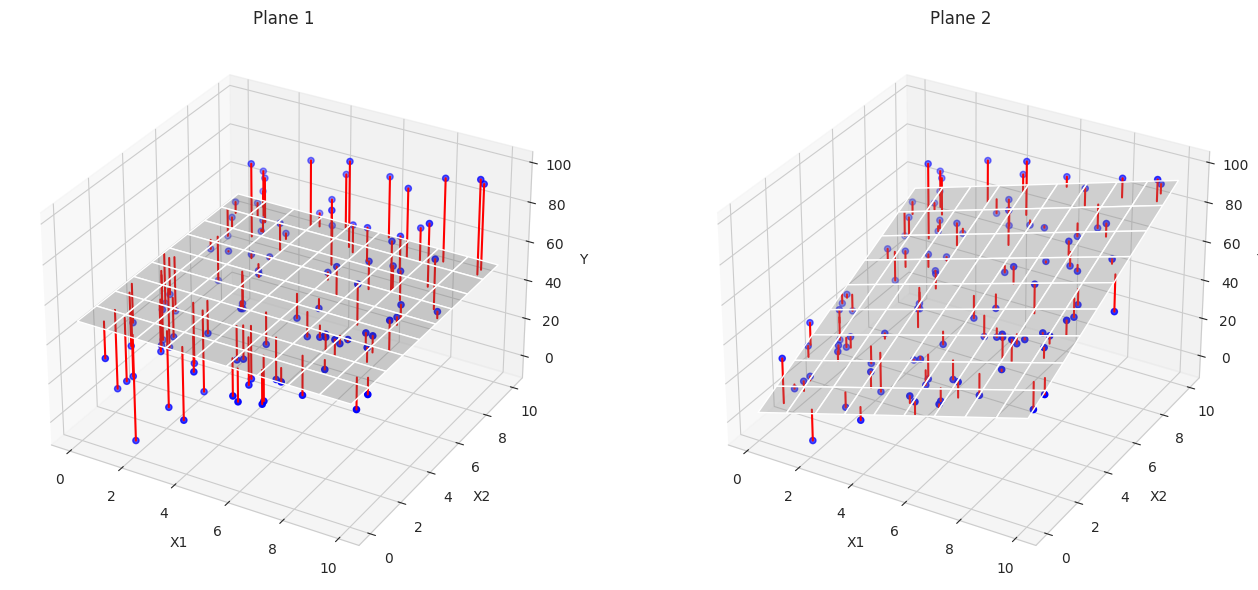

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

# Generate random data
np.random.seed(42)
X1 = np.random.rand(100) * 10
X2 = np.random.rand(100) * 10
Y = 3 + 4 * X1 + 5 * X2 + np.random.randn(100) * 10

# Create a grid of X1, X2 values
X1_grid, X2_grid = np.meshgrid(np.linspace(0, 10, 10), np.linspace(0, 10, 10))

# Y values for the grid
Y_grid = 3 + 4 * X1_grid + 5 * X2_grid

# Plot the data points and a constant plane
fig = plt.figure(figsize=(14, 6))

# Plot the data points
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X1, X2, Y, color='blue', label='Data points')

# Plot a plane where y = 50
ax1.plot_surface(X1_grid, X2_grid, np.full_like(X1_grid, 50), alpha=0.3, color='gray', label='Y = 40')

# Add lines from data points to the plane y = 50
for i in range(len(X1)):
    x1, x2, y = X1[i], X2[i], Y[i]
    ax1.plot([x1, x1], [x2, x2], [y, 50], color='red', linestyle='-')

# Labels and title for the plane y = 50
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('Y')
ax1.set_title('Plane 1')

# Plot the true relationship and projection lines
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X1, X2, Y, color='blue', label='Data points')
ax2.plot_surface(X1_grid, X2_grid, Y_grid, alpha=0.3, color='gray')

# Add lines from data points to the regression plane
for i in range(len(X1)):
    x1, x2, y = X1[i], X2[i], Y[i]
    y_pred = 3 + 4 * x1 + 5 * x2  # Predict Y using the true regression formula
    ax2.plot([x1, x1], [x2, x2], [y, y_pred], color='red', linestyle='-')

# Labels and title for the regression plane
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.set_zlabel('Y')
ax2.set_title('Plane 2')

plt.tight_layout()
plt.show()


Whcih model do you choose? Discuss in your group!

## **Fit the best model**



Intuitively, among all possible models that could describe the data, we want to choose the one that is collectively closest to the observed data points.

For multiple linear regression, the prediction for the $i$th observation (the $i$th house, for example) is

$$
\hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1 X_{i1} + \cdots + \hat{\beta}_p X_{ip}.
$$

This means that we use the features of the $i$th observation to predict its response $\hat{y}_i$.

We can put all the predictions together and write the model more compactly using linear algebra:


$$
\hat{\mathbf{y}} = X\hat{\boldsymbol{\beta}}
$$

where

$$
X =
\begin{bmatrix}
1 & X_{11} & \cdots & X_{1p} \\
1 & X_{21} & \cdots & X_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
1 & X_{n1} & \cdots & X_{np}
\end{bmatrix},
\qquad
\hat{\boldsymbol{\beta}} =
\begin{bmatrix}
\hat{\beta}_0 \\
\hat{\beta}_1 \\
\vdots \\
\hat{\beta}_p
\end{bmatrix}.
$$




For each observation, the difference between the observed value $y_i$ and the predicted value $\hat{y}_i$ is called the **residual**:

$$
e_i = y_i-\hat{y}_i.
$$






We want the predictions to be as close as possible to the observed values. One common way to measure the overall prediction error is the **Mean Squared Error (MSE)**:

$$
MSE = \frac{1}{n}\sum_{i=1}^n(y_i-\hat{y}_i)^2.
$$

The model chooses the coefficients $\hat{\beta}_0,\hat{\beta}_1,\ldots,\hat{\beta}_p$ that minimize the MSE (for example by using calculus to find this minimum).

The **Root Mean Squared Error (RMSE)** is the square root of the MSE:

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^n(y_i-\hat{y}_i)^2}.
$$

In practice, we use software such as Python to find the coefficients that minimize the error. We can then use the fitted model to make predictions for new observations.



## **Implementing Multiple Regression**



In [9]:
#Step 1:
##Prepare data for regression using sklearn
## we need to create a vector of all predictors: $ X = [X_1, X_2]$
X = np.column_stack((X1, X2))



In [10]:
# Step 2: Create a linear regression model and fit the model

## Create a linear regression model
model = LinearRegression()

## Fit the model to the data
model.fit(X, Y)

LinearRegression()

In [11]:
# Get the coefficients and intercept
b0 = model.intercept_
b1, b2 = model.coef_

print(f"Intercept (b0): {b0}")
print(f"Coefficient for X1 (b1): {b1}")
print(f"Coefficient for X2 (b2): {b2}")

Intercept (b0): 2.1061003645007332
Coefficient for X1 (b1): 3.658274678972615
Coefficient for X2 (b2): 5.719311410100673


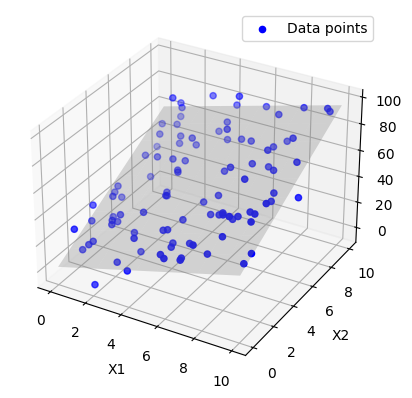

In [ ]:
# Create a 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')  # Add a single axes object

# Plot the data points
ax.scatter(X1, X2, Y, color='blue', label='Data points')

# Plot the regression plane
## Create a grid of X1, X2 values
X1_grid, X2_grid = np.meshgrid(np.linspace(0, 10, 10), np.linspace(0, 10, 10))
## Predict Y values for the grid
Y_grid_regression = b0 + b1 * X1_grid + b2 * X2_grid
## Plot the regression plane
ax.plot_surface(X1_grid, X2_grid, Y_grid_regression, alpha=0.3, color='gray')

# Labels
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Y')
ax.legend()

plt.show()


## **Interpreting the Coefficients**



In multiple linear regression, each coefficient describes how the predicted response changes when one feature increases by one unit, **while keeping the other features constant**.

Suppose we predict house prices using:

* $X_1$: house size (in 100 square feet)
* $X_2$: number of bedrooms
* $X_3$: age of the house (in years)

Suppose the fitted model is:

$$
\widehat{Price}
= 150 + 25X_1 + 15X_2 - 2X_3.
$$

| Feature  | Coefficient | Interpretation                                                                                                                   |
| -------- | ----------: | -------------------------------------------------------------------------------------------------------------------------------- |
| Size     |          25 | An additional 100 square feet is associated with a **\$25,000 increase** in predicted price, holding the other features constant. |
| Bedrooms |          15 | One additional bedroom is associated with a **$15,000 increase** in predicted price, holding the other features constant.        |
| Age      |          -2 | Each additional year of age is associated with a **\$2,000 decrease** in predicted price, holding the other features constant.    |

### A Note About Correlated Features

The interpretation becomes more difficult when features are strongly related to each other.

For example, larger houses often have more bedrooms. It may therefore be difficult to separate the individual effects of **size** and **number of bedrooms**.

This is one reason we should be careful when interpreting individual coefficients in a multiple regression model.
